In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity

In [3]:
movies = pd.read_csv("data/movies.csv")
ratings = pd.read_csv("data/ratings.csv")

In [4]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [6]:
data = pd.merge(ratings, movies, on='movieId')

In [7]:
data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [8]:
user_movie_matrix = data.pivot_table(
    index='userId',
    columns='title',
    values='rating'
)

In [9]:
filled_matrix = user_movie_matrix.fillna(0)

In [10]:
from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity(filled_matrix)

similarity_df = pd.DataFrame(
    similarity,
    index=user_movie_matrix.index,
    columns=user_movie_matrix.index
)

In [11]:
print(user_movie_matrix.loc[1].dropna().head())

title
13th Warrior, The (1999)                4.0
20 Dates (1998)                         4.0
Abyss, The (1989)                       4.0
Adventures of Robin Hood, The (1938)    5.0
Alice in Wonderland (1951)              5.0
Name: 1, dtype: float64


In [12]:
print(user_movie_matrix.loc[266].dropna().head())

title
2001: A Space Odyssey (1968)    5.0
Abyss, The (1989)               4.0
Airplane! (1980)                1.0
Aliens (1986)                   5.0
American Pie (1999)             1.0
Name: 266, dtype: float64


In [13]:
user_id = 1

similar_users = similarity_df[user_id].sort_values(ascending=False)

print(similar_users.head(10))

userId
1      1.000000
266    0.357408
313    0.351562
368    0.345127
57     0.345034
91     0.334727
469    0.330664
39     0.329782
288    0.329700
452    0.328048
Name: 1, dtype: float64


In [21]:
movie_stats = data.groupby('title').agg({
    'rating': ['mean', 'count']
})

movie_stats.columns = ['avg_rating', 'rating_count']

movie_stats = movie_stats.reset_index()

movie_stats.head()

,title,avg_rating,rating_count
0,'71 (2014),4.0,1
1,'Hellboy': The Seeds of Creation (2004),4.0,1
2,'Round Midnight (1986),3.5,2
3,'Salem's Lot (2004),5.0,1
4,'Til There Was You (1997),4.0,2


In [22]:
popular_movies = movie_stats[movie_stats['rating_count'] > 50]

popular_movies.head()

,title,avg_rating,rating_count
18,10 Things I Hate About You (1999),3.527778,54
34,12 Angry Men (1957),4.149123,57
74,2001: A Space Odyssey (1968),3.894495,109
89,28 Days Later (2002),3.974138,58
104,300 (2007),3.681250,80


In [31]:
def recommend_movies(user_id,
                     num_recommendations=10,
                     genre=None):

    similar_users = similarity_df[user_id] \
                        .sort_values(ascending=False)[1:11]

    watched_movies = set(
        user_movie_matrix.loc[user_id]
        .dropna()
        .index
    )

    weighted_scores = pd.Series(dtype=float)

    for similar_user, similarity_score in similar_users.items():

        similar_user_ratings = user_movie_matrix.loc[similar_user].dropna()

        for movie, rating in similar_user_ratings.items():

            if movie not in watched_movies:

                if movie not in weighted_scores.index:
                    weighted_scores[movie] = 0.0

                weighted_scores[movie] += rating * similarity_score

    recommendations = weighted_scores.sort_values(ascending=False)

    recommendations_df = recommendations.reset_index()
    recommendations_df.columns = ['title', 'score']

    recommendations_df = recommendations_df.merge(
        movie_stats,
        on='title'
    )

    recommendations_df = recommendations_df.merge(
        movies[['title', 'genres']],
        on='title'
    )

    recommendations_df = recommendations_df[
        recommendations_df['rating_count'] > 50
    ]

    if genre:
        recommendations_df = recommendations_df[
            recommendations_df['genres'].str.contains(
                genre,
                case=False,
                na=False
            )
        ]

    return recommendations_df.head(num_recommendations)

In [32]:
recommend_movies(1)



,title,score,avg_rating,rating_count,genres
0,Terminator 2: Judgment Day (1991),14.182299,3.970982,224,Action|Sci-Fi
1,Aliens (1986),13.925162,3.964286,126,Action|Adventure|Horror|Sci-Fi
2,"Sixth Sense, The (1999)",13.422015,3.893855,179,Drama|Horror|Mystery
3,"Hunt for Red October, The (1990)",13.377867,3.872222,90,Action|Adventure|Thriller
4,"Godfather, The (1972)",13.134550,4.289062,192,Crime|Drama
5,2001: A Space Odyssey (1968),13.031035,3.894495,109,Adventure|Drama|Sci-Fi
6,Die Hard (1988),12.862273,3.862069,145,Action|Crime|Thriller
7,Blade Runner (1982),12.539779,4.100806,124,Action|Sci-Fi|Thriller
8,"Godfather: Part II, The (1974)",12.104995,4.259690,129,Crime|Drama
9,"Breakfast Club, The (1985)",12.080897,3.778761,113,Comedy|Drama


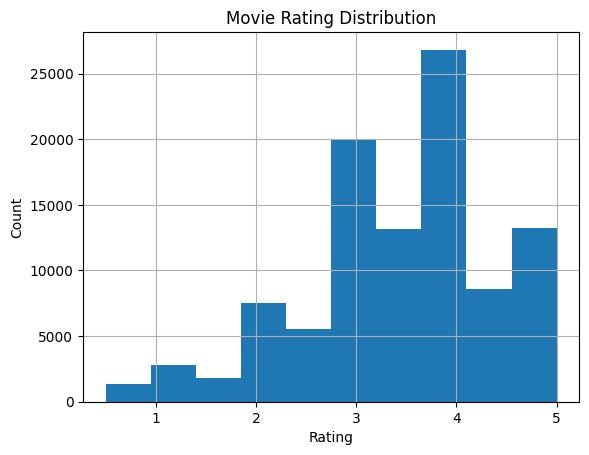

In [33]:
import matplotlib.pyplot as plt

data['rating'].hist(bins=10)

plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Movie Rating Distribution")

plt.show()

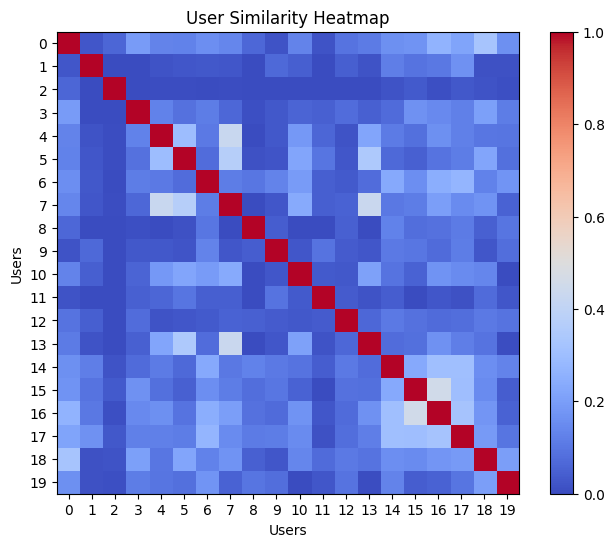

In [34]:
plt.figure(figsize=(8,6))

plt.imshow(similarity_df.iloc[:20, :20], cmap='coolwarm')

plt.colorbar()

plt.xticks(range(20))
plt.yticks(range(20))

plt.title("User Similarity Heatmap")

plt.xlabel("Users")
plt.ylabel("Users")

plt.show()

In [35]:
def show_user_movies(user_id, n=10):

    watched = user_movie_matrix.loc[user_id].dropna()

    watched = watched.sort_values(ascending=False)

    return watched.head(n)

In [36]:
show_user_movies(1)

title
Adventures of Robin Hood, The (1938)                  5.0
American Beauty (1999)                                5.0
All Quiet on the Western Front (1930)                 5.0
Alice in Wonderland (1951)                            5.0
Back to the Future (1985)                             5.0
Austin Powers: International Man of Mystery (1997)    5.0
American Tail, An (1986)                              5.0
American History X (1998)                             5.0
Conan the Barbarian (1982)                            5.0
Clockwork Orange, A (1971)                            5.0
Name: 1, dtype: float64

In [37]:
recommend_movies(1, genre="Action")

,title,score,avg_rating,rating_count,genres
0,Terminator 2: Judgment Day (1991),14.182299,3.970982,224,Action|Sci-Fi
1,Aliens (1986),13.925162,3.964286,126,Action|Adventure|Horror|Sci-Fi
3,"Hunt for Red October, The (1990)",13.377867,3.872222,90,Action|Adventure|Thriller
6,Die Hard (1988),12.862273,3.862069,145,Action|Crime|Thriller
7,Blade Runner (1982),12.539779,4.100806,124,Action|Sci-Fi|Thriller
10,Star Trek II: The Wrath of Khan (1982),12.010755,3.766129,62,Action|Adventure|Sci-Fi|Thriller
14,"Fifth Element, The (1997)",11.082213,3.745690,116,Action|Adventure|Comedy|Sci-Fi
15,Jaws (1975),11.044927,4.005495,91,Action|Horror
16,True Lies (1994),10.608554,3.497191,178,Action|Adventure|Comedy|Romance|Thriller
21,Star Trek: First Contact (1996),9.754597,3.879121,91,Action|Adventure|Sci-Fi|Thriller


In [38]:
recommend_movies(1, genre="Comedy")

,title,score,avg_rating,rating_count,genres
9,"Breakfast Club, The (1985)",12.080897,3.778761,113,Comedy|Drama
13,Airplane! (1980),11.286763,3.856322,87,Comedy
14,"Fifth Element, The (1997)",11.082213,3.745690,116,Action|Adventure|Comedy|Sci-Fi
16,True Lies (1994),10.608554,3.497191,178,Action|Adventure|Comedy|Romance|Thriller
17,Ferris Bueller's Day Off (1986),10.422671,3.839450,109,Comedy
19,Raising Arizona (1987),10.145790,3.991379,58,Comedy
25,"Fish Called Wanda, A (1988)",9.103110,3.922535,71,Comedy|Crime
27,Mars Attacks! (1996),8.758350,3.093023,86,Action|Comedy|Sci-Fi
30,Army of Darkness (1993),8.463368,4.039216,51,Action|Adventure|Comedy|Fantasy|Horror
33,Shakespeare in Love (1998),8.345417,3.777174,92,Comedy|Drama|Romance
